# Maps 

Author: Kat Le

Maps for faculty review and final presentations.

In [7]:
# Load packages 
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn
from matplotlib import colors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm
from matplotlib import colors as mcolors

In [8]:
pd.set_option('display.max_columns', None)

# Read in GeoJSON of all 
national_results = gpd.read_file('/capstone/justice40/github/j40-cejst-2/data/data-pipeline/data_pipeline/data/score/geojson/gi-star-values.geojson')
national_results.head()

#national_results = gpd.read_file('/capstone/justice40/github/j40-cejst-2/data/data-pipeline/data_pipeline/data/score/geojson/gistar/burd/usa-high-gistar-burd.json')
#national_results.head()

,tract_id,county,state,tot_burden,gi_burd,pnorm_burd,tot_indica,gi_ind,pnorm_ind,dac,population,G_STR_BUR,C_ID_BUR,PP_VAL_BUR,G_STR_IND,C_ID_IND,PP_VAL_IND,geometry
0,1001020100,Autauga County,Alabama,0.0,-0.620617,0.267426,0,-0.560448,0.287587,0,1993.0,0.0,2,0.0001,0.0,2,0.0001,"MULTIPOLYGON (((-86.48196 32.49876, -86.48189 ..."
1,1001020200,Autauga County,Alabama,0.0,-0.620617,0.267426,0,-0.560448,0.287587,0,1959.0,0.0,2,0.0001,0.0,2,0.0001,"MULTIPOLYGON (((-86.46828 32.4737, -86.468 32...."
2,1001020300,Autauga County,Alabama,0.0,-0.620617,0.267426,0,-0.560448,0.287587,0,3507.0,0.0,2,0.0001,0.0,2,0.0001,"MULTIPOLYGON (((-86.46538 32.47372, -86.46597 ..."
3,1001020400,Autauga County,Alabama,0.0,-0.620617,0.267426,0,-0.560448,0.287587,0,3878.0,0.0,2,0.0001,0.0,2,0.0001,"MULTIPOLYGON (((-86.43807 32.45349, -86.43812 ..."
4,1001020500,Autauga County,Alabama,0.0,-0.620617,0.267426,0,-0.560448,0.287587,0,10596.0,0.0,2,0.0001,0.0,2,0.0001,"MULTIPOLYGON (((-86.4118 32.47416, -86.4118 32..."


In [9]:
national_results.describe()

,tract_id,tot_burden,gi_burd,pnorm_burd,tot_indica,gi_ind,pnorm_ind,dac,population,G_STR_BUR,C_ID_BUR,PP_VAL_BUR,G_STR_IND,C_ID_IND,PP_VAL_IND
count,7.376700e+04,73767.000000,73767.000000,73767.000000,73767.000000,73767.000000,73767.000000,73767.000000,73767.000000,73767.000000,73767.000000,73767.000000,73767.000000,73767.000000,73767.000000
mean,2.843865e+10,1.115892,-0.011811,0.296791,1.611303,-0.011641,0.309575,0.387273,4449.556482,0.000013,0.875351,0.121683,0.000013,0.855450,0.130048
std,1.652436e+10,1.798065,0.762386,0.112602,2.875070,0.774223,0.111376,0.487130,2332.984933,0.000017,0.915179,0.150270,0.000019,0.920826,0.155277
min,1.001020e+09,0.000000,-0.620617,0.000000,0.000000,-0.560452,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.304591e+10,0.000000,-0.620617,0.267426,0.000000,-0.560448,0.287587,0.000000,2913.000000,0.000000,0.000000,0.000100,0.000000,0.000000,0.000100
50%,2.804901e+10,0.000000,-0.302814,0.267431,0.000000,-0.328569,0.290274,0.000000,4125.000000,0.000007,1.000000,0.044400,0.000006,0.000000,0.054300
75%,4.200347e+10,2.000000,0.332791,0.377656,2.000000,0.212519,0.382247,1.000000,5556.000000,0.000021,2.000000,0.224200,0.000019,2.000000,0.239900
max,7.803096e+10,8.000000,3.550685,0.498957,18.000000,5.283995,0.499437,1.000000,72041.000000,0.000091,3.000000,0.500000,0.000142,3.000000,0.500000


# Assgn cluster categories to df

In [10]:
# Burdens - 95% significance
def assign_95_bur(row):
    if row['C_ID_BUR'] == 0 or row['PP_VAL_BUR'] >= 0.05:
        return 'Not significant'
    elif row['C_ID_BUR'] == 1:
        return '95% Hot Spot'
    elif row['C_ID_BUR'] == 2:
        return '95% Cold Spot'
    return 'Not significant'

# Burdens - 99% significance
def assign_99_bur(row):
    if row['C_ID_BUR'] == 0 or row['PP_VAL_BUR'] >= 0.01:
        return 'Not significant'
    elif row['C_ID_BUR'] == 1:
        return '99% Hot Spot'
    elif row['C_ID_BUR'] == 2:
        return '99% Cold Spot'
    return 'Not significant'

# Indicators - 95% significance
def assign_95_ind(row):
    if row['C_ID_IND'] == 0 or row['PP_VAL_IND'] >= 0.05:
        return 'Not significant'
    elif row['C_ID_IND'] == 1:
        return '95% Hot Spot'
    elif row['C_ID_IND'] == 2:
        return '95% Cold Spot'
    return 'Not significant'

# Indicators - 99% significance
def assign_99_ind(row):
    if row['C_ID_IND'] == 0 or row['PP_VAL_IND'] >= 0.01:
        return 'Not significant'
    elif row['C_ID_IND'] == 1:
        return '99% Hot Spot'
    elif row['C_ID_IND'] == 2:
        return '99% Cold Spot'
    return 'Not significant'

# Apply all functions
national_results['cluster_95_bur'] = national_results.apply(assign_95_bur, axis=1)
national_results['cluster_99_bur'] = national_results.apply(assign_99_bur, axis=1)
national_results['cluster_95_ind'] = national_results.apply(assign_95_ind, axis=1)
national_results['cluster_99_ind'] = national_results.apply(assign_99_ind, axis=1)

In [11]:
national_results.head()

,tract_id,county,state,tot_burden,gi_burd,pnorm_burd,tot_indica,gi_ind,pnorm_ind,dac,population,G_STR_BUR,C_ID_BUR,PP_VAL_BUR,G_STR_IND,C_ID_IND,PP_VAL_IND,geometry,cluster_95_bur,cluster_99_bur,cluster_95_ind,cluster_99_ind
0,1001020100,Autauga County,Alabama,0.0,-0.620617,0.267426,0,-0.560448,0.287587,0,1993.0,0.0,2,0.0001,0.0,2,0.0001,"MULTIPOLYGON (((-86.48196 32.49876, -86.48189 ...",95% Cold Spot,99% Cold Spot,95% Cold Spot,99% Cold Spot
1,1001020200,Autauga County,Alabama,0.0,-0.620617,0.267426,0,-0.560448,0.287587,0,1959.0,0.0,2,0.0001,0.0,2,0.0001,"MULTIPOLYGON (((-86.46828 32.4737, -86.468 32....",95% Cold Spot,99% Cold Spot,95% Cold Spot,99% Cold Spot
2,1001020300,Autauga County,Alabama,0.0,-0.620617,0.267426,0,-0.560448,0.287587,0,3507.0,0.0,2,0.0001,0.0,2,0.0001,"MULTIPOLYGON (((-86.46538 32.47372, -86.46597 ...",95% Cold Spot,99% Cold Spot,95% Cold Spot,99% Cold Spot
3,1001020400,Autauga County,Alabama,0.0,-0.620617,0.267426,0,-0.560448,0.287587,0,3878.0,0.0,2,0.0001,0.0,2,0.0001,"MULTIPOLYGON (((-86.43807 32.45349, -86.43812 ...",95% Cold Spot,99% Cold Spot,95% Cold Spot,99% Cold Spot
4,1001020500,Autauga County,Alabama,0.0,-0.620617,0.267426,0,-0.560448,0.287587,0,10596.0,0.0,2,0.0001,0.0,2,0.0001,"MULTIPOLYGON (((-86.4118 32.47416, -86.4118 32...",95% Cold Spot,99% Cold Spot,95% Cold Spot,99% Cold Spot


/tmp/ipykernel_2222076/2911624029.py:11: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  (national_results.geometry.centroid.x > -125) &
/tmp/ipykernel_2222076/2911624029.py:12: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  (national_results.geometry.centroid.x < -66) &
/tmp/ipykernel_2222076/2911624029.py:13: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  (national_results.geometry.centroid.y > 24) &
/tmp/ipykernel_2222076/2911624029.py:14: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geo

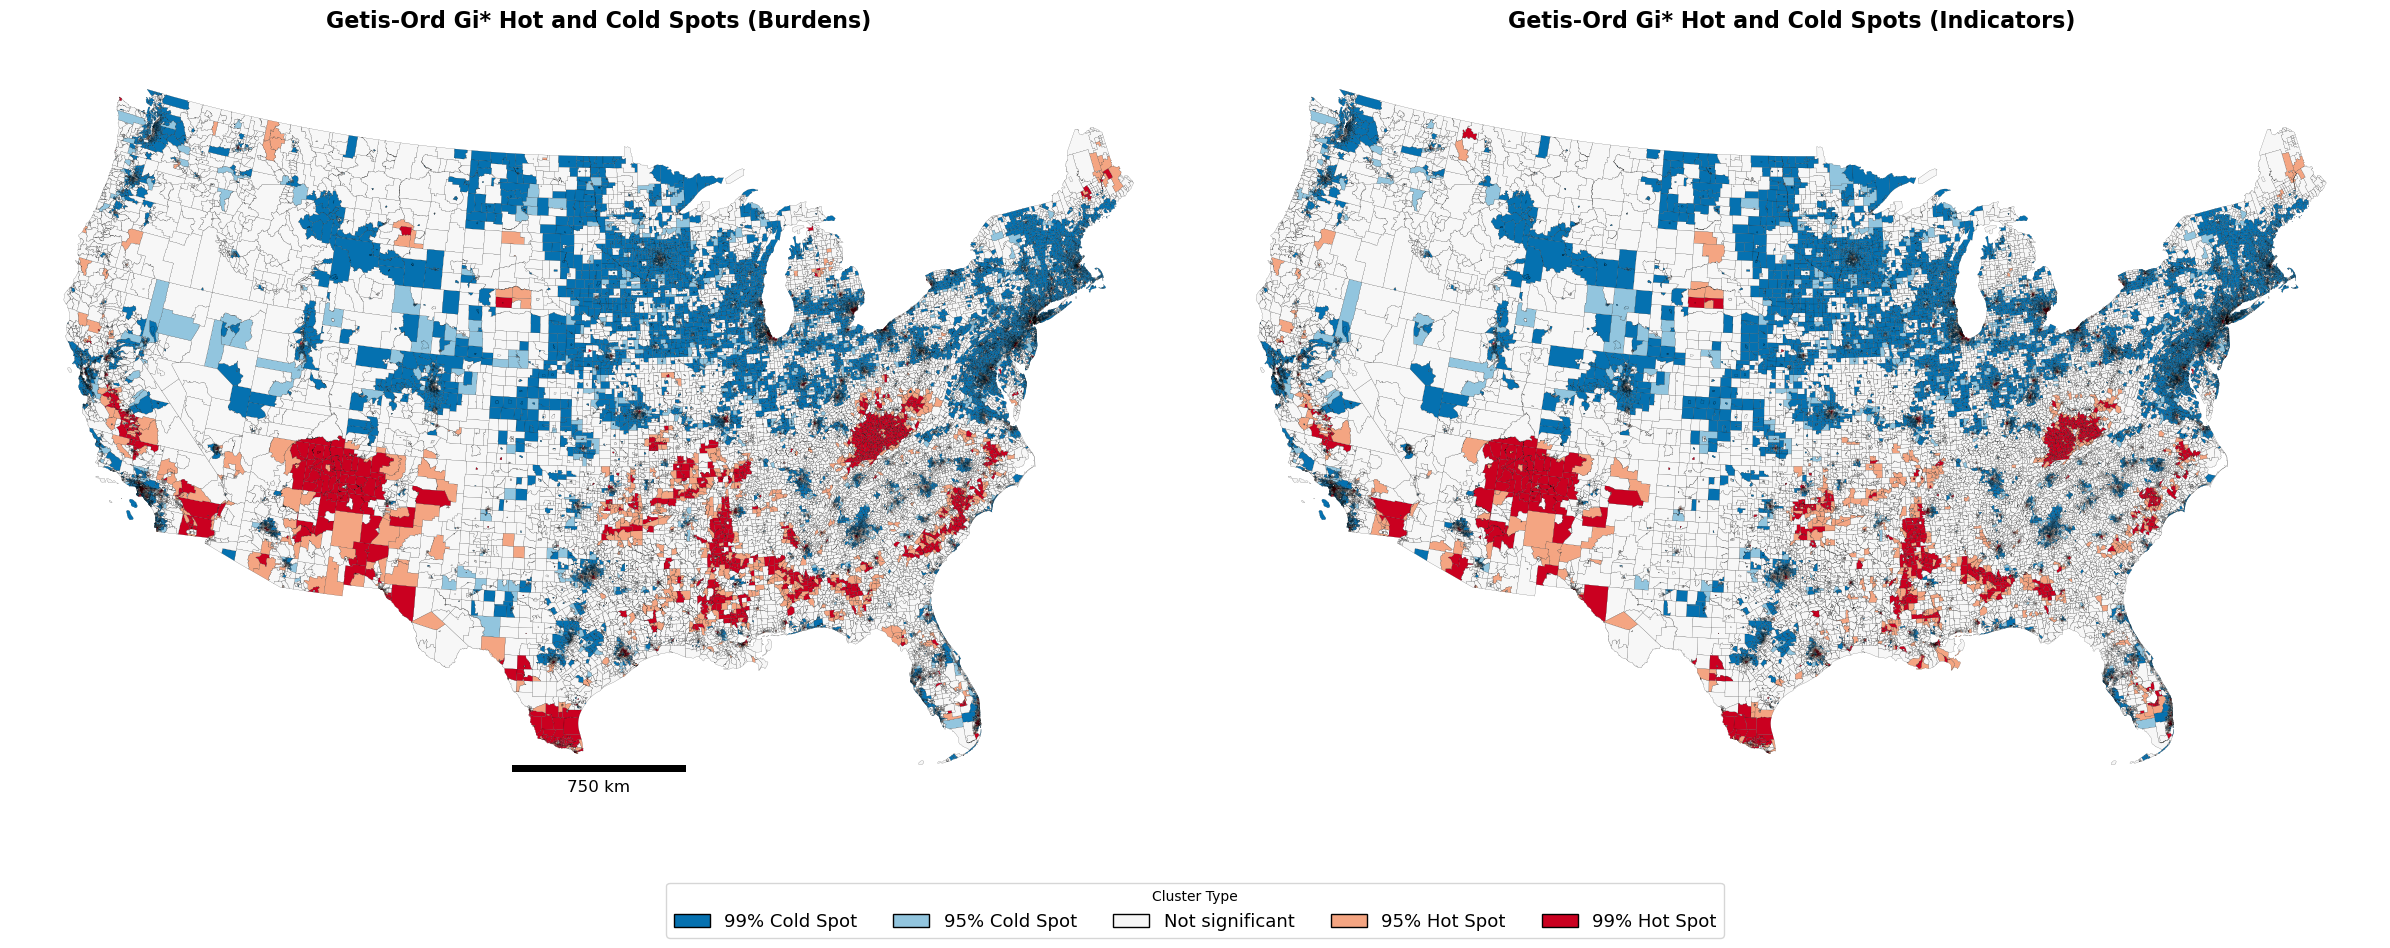

In [12]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.patches import Patch
import numpy as np
import pandas as pd

# Filter to contiguous US and reproject
contiguous_mask = (
    (national_results.geometry.centroid.x > -125) & 
    (national_results.geometry.centroid.x < -66) & 
    (national_results.geometry.centroid.y > 24) & 
    (national_results.geometry.centroid.y < 50)
)
contiguous_us = national_results[contiguous_mask].copy().to_crs('ESRI:102003')

# Create combined cluster category with all levels for burdens
def assign_all_clusters_bur(row):
    if row['C_ID_BUR'] == 0 or row['PP_VAL_BUR'] >= 0.05:
        return 'Not significant'
    elif row['C_ID_BUR'] == 1:
        if row['PP_VAL_BUR'] < 0.01:
            return '99% Hot Spot'
        else:
            return '95% Hot Spot'
    elif row['C_ID_BUR'] == 2:
        if row['PP_VAL_BUR'] < 0.01:
            return '99% Cold Spot'
        else:
            return '95% Cold Spot'
    return 'Not significant'

# Create combined cluster category with all levels for indicators
def assign_all_clusters_ind(row):
    if row['C_ID_IND'] == 0 or row['PP_VAL_IND'] >= 0.05:
        return 'Not significant'
    elif row['C_ID_IND'] == 1:
        if row['PP_VAL_IND'] < 0.01:
            return '99% Hot Spot'
        else:
            return '95% Hot Spot'
    elif row['C_ID_IND'] == 2:
        if row['PP_VAL_IND'] < 0.01:
            return '99% Cold Spot'
        else:
            return '95% Cold Spot'
    return 'Not significant'

contiguous_us['cluster_all_bur'] = contiguous_us.apply(assign_all_clusters_bur, axis=1)
contiguous_us['cluster_all_ind'] = contiguous_us.apply(assign_all_clusters_ind, axis=1)

# Define colors for all categories (in desired legend order)
categories = ['99% Cold Spot', '95% Cold Spot', 'Not significant', '95% Hot Spot', '99% Hot Spot']
colors_dict = {
    'Not significant': '#f7f7f7',
    '95% Cold Spot': '#92c5de',
    '99% Cold Spot': '#0571b0',
    '95% Hot Spot': '#f4a582',
    '99% Hot Spot': '#ca0020'
}

# Create figure with two subplots and extra space for shared legend
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10))

# Plot burdens
contiguous_us.plot(
    column='cluster_all_bur',
    categorical=True,
    legend=False,
    color=[colors_dict.get(cat, '#f7f7f7') for cat in contiguous_us['cluster_all_bur']],
    linewidth=0.1,
    edgecolor='black',
    ax=ax1
)
ax1.set_title('Getis-Ord Gi* Hot and Cold Spots (Burdens)', fontsize=16, fontweight='bold', pad=20)
ax1.set_axis_off()

# Plot indicators
contiguous_us.plot(
    column='cluster_all_ind',
    categorical=True,
    legend=False,
    color=[colors_dict.get(cat, '#f7f7f7') for cat in contiguous_us['cluster_all_ind']],
    linewidth=0.1,
    edgecolor='black',
    ax=ax2
)
ax2.set_title('Getis-Ord Gi* Hot and Cold Spots (Indicators)', fontsize=16, fontweight='bold', pad=20)
ax2.set_axis_off()

# Add single scalebar to the figure (positioned between maps)
scalebar = ScaleBar(
    1,
    dimension='si-length', 
    units='m', 
    location='lower center', 
    box_alpha=0.5,
    length_fraction=0.15,
    font_properties={'size': 12}
)
ax1.add_artist(scalebar)

# Create shared legend for the entire figure
legend_elements = [Patch(facecolor=colors_dict[cat], edgecolor='black', label=cat) 
                   for cat in categories]
fig.legend(handles=legend_elements, loc='lower center', fontsize=13, frameon=True, 
           title='Cluster Type', ncol=5, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig('../images/gistar_bur_ind_comparison.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

# Total burdens versus Total Indicators

/tmp/ipykernel_2222076/2132265147.py:10: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  (national_results.geometry.centroid.x > -125) &
/tmp/ipykernel_2222076/2132265147.py:11: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  (national_results.geometry.centroid.x < -66) &
/tmp/ipykernel_2222076/2132265147.py:12: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  (national_results.geometry.centroid.y > 24) &
/tmp/ipykernel_2222076/2132265147.py:13: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geo

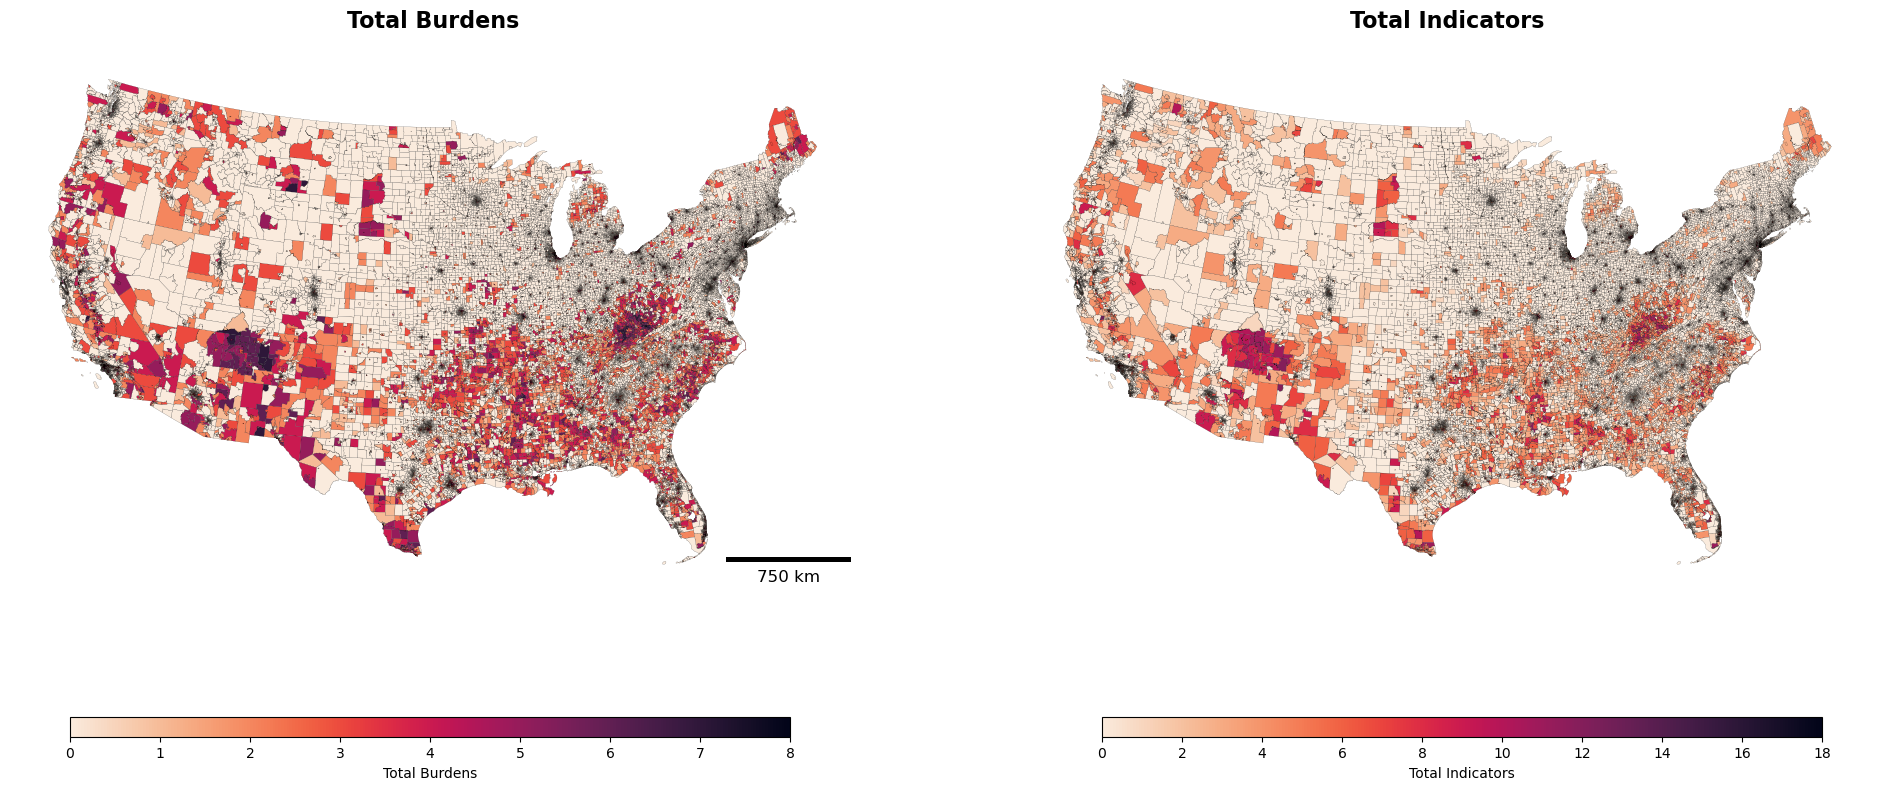

In [13]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.colorbar import ColorbarBase
from matplotlib_scalebar.scalebar import ScaleBar
import numpy as np

# Filter to contiguous US and reproject
contiguous_mask = (
    (national_results.geometry.centroid.x > -125) & 
    (national_results.geometry.centroid.x < -66) & 
    (national_results.geometry.centroid.y > 24) & 
    (national_results.geometry.centroid.y < 50)
)
contiguous_us = national_results[contiguous_mask].copy().to_crs('ESRI:102003')

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10))

# Set up colormaps
vmin_bur = contiguous_us['tot_burden'].min()
vmax_bur = contiguous_us['tot_burden'].max()
norm_bur = colors.Normalize(vmin=vmin_bur, vmax=vmax_bur)
cmap = plt.cm.get_cmap('rocket_r')

vmin_ind = contiguous_us['tot_indica'].min()
vmax_ind = contiguous_us['tot_indica'].max()
norm_ind = colors.Normalize(vmin=vmin_ind, vmax=vmax_ind)

# Plot burdens
contiguous_us.plot(
    column='tot_burden',
    cmap=cmap,
    norm=norm_bur,
    linewidth=0.1,
    edgecolor='black',
    ax=ax1
)
ax1.set_title('Total Burdens', fontsize=16, fontweight='bold', pad=20)
ax1.set_axis_off()

# Plot indicators
contiguous_us.plot(
    column='tot_indica',
    cmap=cmap,
    norm=norm_ind,
    linewidth=0.1,
    edgecolor='black',
    ax=ax2
)
ax2.set_title('Total Indicators', fontsize=16, fontweight='bold', pad=20)
ax2.set_axis_off()

# Add scalebar (shared, on first plot)
scalebar = ScaleBar(
    1,  # dx=1 for Albers (already in meters)
    dimension='si-length', 
    units='m', 
    location='lower right', 
    box_alpha=0.5,
    length_fraction=0.15,
    font_properties={'size': 12}
)
ax1.add_artist(scalebar)

# Add horizontal colorbars at the bottom
cbar_ax1 = fig.add_axes([0.15, 0.08, 0.3, 0.02])  # [left, bottom, width, height] - Burdens
ColorbarBase(
    cbar_ax1, 
    cmap=cmap,
    norm=norm_bur,
    orientation='horizontal', 
    label='Total Burdens'
)

cbar_ax2 = fig.add_axes([0.58, 0.08, 0.3, 0.02])  # Indicators
ColorbarBase(
    cbar_ax2, 
    cmap=cmap,
    norm=norm_ind,
    orientation='horizontal', 
    label='Total Indicators'
)

plt.savefig('../images/tot_burd_ind_comparison.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

# Binary classification

/tmp/ipykernel_2222076/2322629932.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  (national_results.geometry.centroid.x > -125) &
/tmp/ipykernel_2222076/2322629932.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  (national_results.geometry.centroid.x < -66) &
/tmp/ipykernel_2222076/2322629932.py:10: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  (national_results.geometry.centroid.y > 24) &
/tmp/ipykernel_2222076/2322629932.py:11: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geome

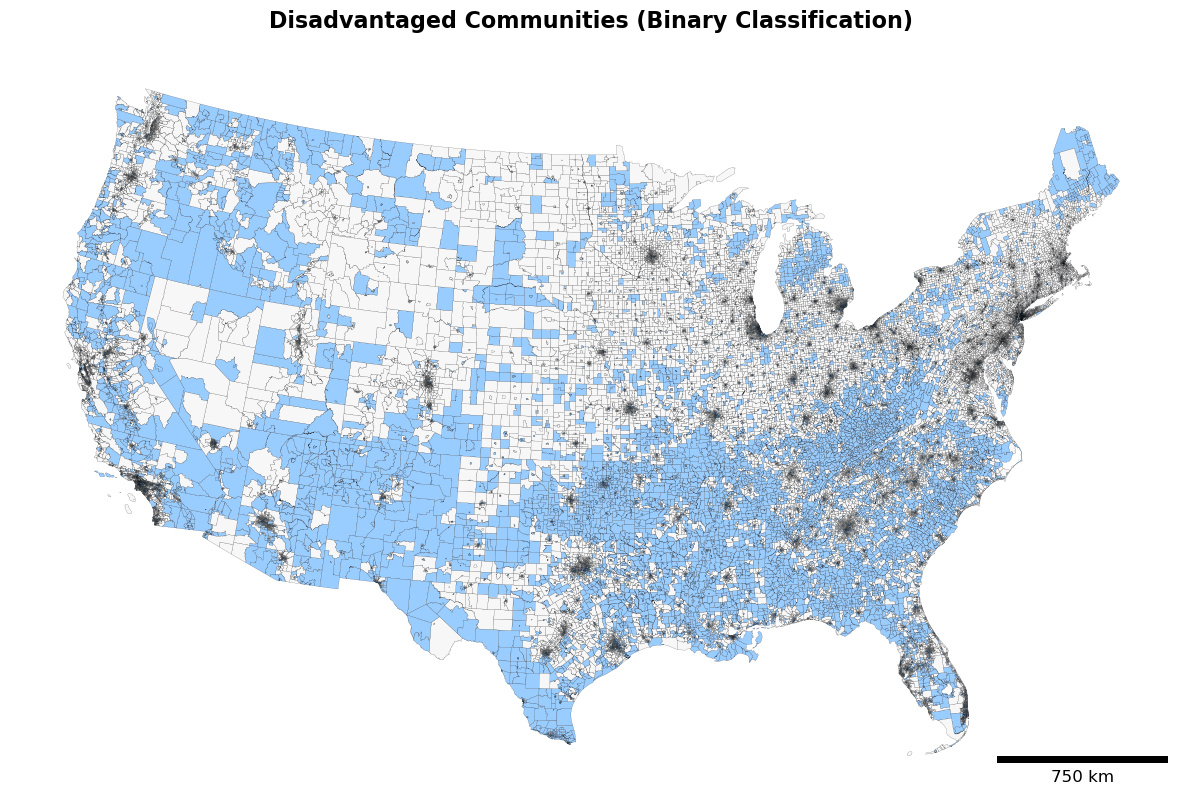

In [14]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
import numpy as np

# Filter to contiguous US and reproject
contiguous_mask = (
    (national_results.geometry.centroid.x > -125) & 
    (national_results.geometry.centroid.x < -66) & 
    (national_results.geometry.centroid.y > 24) & 
    (national_results.geometry.centroid.y < 50)
)
contiguous_us = national_results[contiguous_mask].copy().to_crs('ESRI:102003')

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Define colors: 0 = light gray, 1 = blue
colors_dict = {0: '#f7f7f7', 1: '#99CCFF'}

# Plot the data
contiguous_us.plot(
    column='dac',
    categorical=True,
    legend=False,
    color=[colors_dict.get(val, '#f7f7f7') for val in contiguous_us['dac']],
    linewidth=0.1,
    edgecolor='black',
    ax=ax
)

ax.set_title('Disadvantaged Communities (Binary Classification)', fontsize=16, fontweight='bold', pad=20)
ax.set_axis_off()

# Add scalebar
scalebar = ScaleBar(
    1,  # dx=1 for Albers (already in meters)
    dimension='si-length', 
    units='m', 
    location='lower right', 
    box_alpha=0.5,
    length_fraction=0.15,
    font_properties={'size': 12}
)
ax.add_artist(scalebar)

plt.savefig('../images/dac_map.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()